# Support Vector Machines

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import load_iris
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)  # Iris virginica

model1 = LinearSVC(C=1.E-2)
model1.fit(X, y)
print(model1.score)

X_new = [[5.5, 1.7], [5.0, 1.5]]

model1.predict(X_new)

<bound method ClassifierMixin.score of LinearSVC(C=0.01)>


array([ True, False])

[ True False]
0.9666666666666667
[ 1.42243259 -0.11976094]


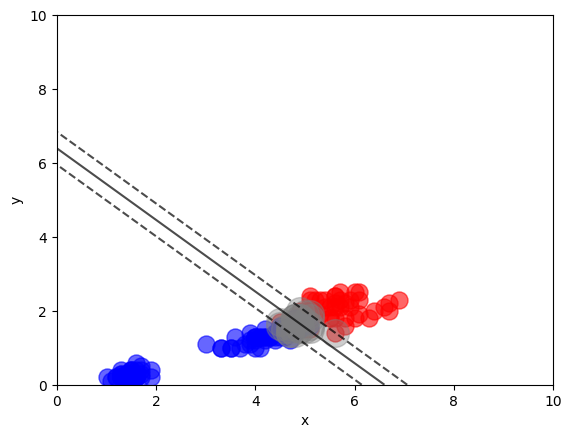

In [10]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)  # Iris virginica

model1 = SVC(kernel='linear', C=1)
model1.fit(X, y)
model1.score(X, y)

X_new = [[5.5, 1.7], [5.0, 1.5]]

print(model1.predict(X_new))
print(model1.score(X,y))
print(model1.decision_function(X_new))

xlim = [0,10]
ylim = [0,10]  

plt.scatter(X[y==1][:,0],X[y==1][:,1], s = 150, marker='o',alpha=0.6, c='r')
plt.scatter(X[y==0][:,0],X[y==0][:,1], s = 150, marker='o',alpha=0.6, c='b')
plt.xlim(xlim[0],xlim[1])
plt.ylim(ylim[0],ylim[1])
plt.xlabel('x')
plt.ylabel('y')

NBINS = 25
xg = np.linspace(xlim[0], xlim[1], NBINS)
yg = np.linspace(ylim[0], ylim[1], NBINS)
Yg, Xg = np.meshgrid(yg, xg)
xy = np.vstack([Xg.ravel(), Yg.ravel()]).T
P1 = model1.decision_function(xy).reshape(Xg.shape)

# Trenngerade und Fehlergrenzen
cont = plt.contour(Xg, Yg, P1, colors='k',
                levels=[-1, 0, 1], alpha=0.7,
                linestyles=['--', '-', '--'])
#plt.setp(cont.collections,lw=2)
# Srützvektoren:
plt.scatter(model1.support_vectors_[:, 0],model1.support_vectors_[:, 1],s=400, facecolors='grey',alpha=0.39)

[ True  True]
0.9533333333333334
[12.81705639 11.28179161]


C:\Users\gilg\AppData\Local\Temp\ipykernel_10524\261327200.py:44: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(cont.collections,lw=2)


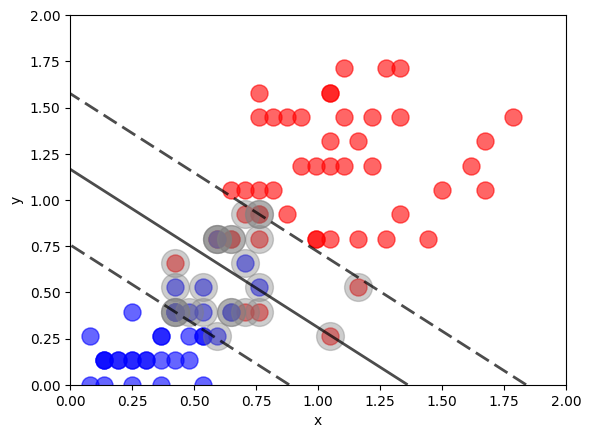

In [ ]:

model2 = SVC(kefrom sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)  # Iris virginica

X = StandardScaler().fit_transform(X)
rnel='linear', C=1)
model2.fit(X, y)
model2.score(X, y)

X_new = [[5.5, 1.7], [5.0, 1.5]]

print(model2.predict(X_new))
print(model2.score(X,y))
print(model2.decision_function(X_new))

# Plotting
xlim = [0,2]
ylim = [0,2]

plt.scatter(X[y==1][:,0],X[y==1][:,1], s = 150, marker='o',alpha=0.6, c='r')
plt.scatter(X[y==0][:,0],X[y==0][:,1], s = 150, marker='o',alpha=0.6, c='b')
plt.xlim(xlim[0],xlim[1])
plt.ylim(ylim[0],ylim[1])
plt.xlabel('x')
plt.ylabel('y')

NBINS = 25
xg = np.linspace(xlim[0], xlim[1], NBINS)
yg = np.linspace(ylim[0], ylim[1], NBINS)
Yg, Xg = np.meshgrid(yg, xg)
xy = np.vstack([Xg.ravel(), Yg.ravel()]).T
P1 = model2.decision_function(xy).reshape(Xg.shape)

# Trenngerade und Fehlergrenzen
cont = plt.contour(Xg, Yg, P1, colors='k',
                levels=[-1, 0, 1], alpha=0.7,
                linestyles=['--', '-', '--'])
plt.setp(cont.collections,lw=2)
# Stützvektoren
plt.scatter(model2.support_vectors_[:, 0],model2.support_vectors_[:, 1],s=400, facecolors='grey',alpha=0.39)

In [ ]:
X = iris.data
y = iris.target

model_nonlinear = SVC(kernel='rbf', C=1, gamma=1) # C = 1000, 
model_nonlinear.fit(X, y)
print(model_nonlinear.score(X,y))

0.98


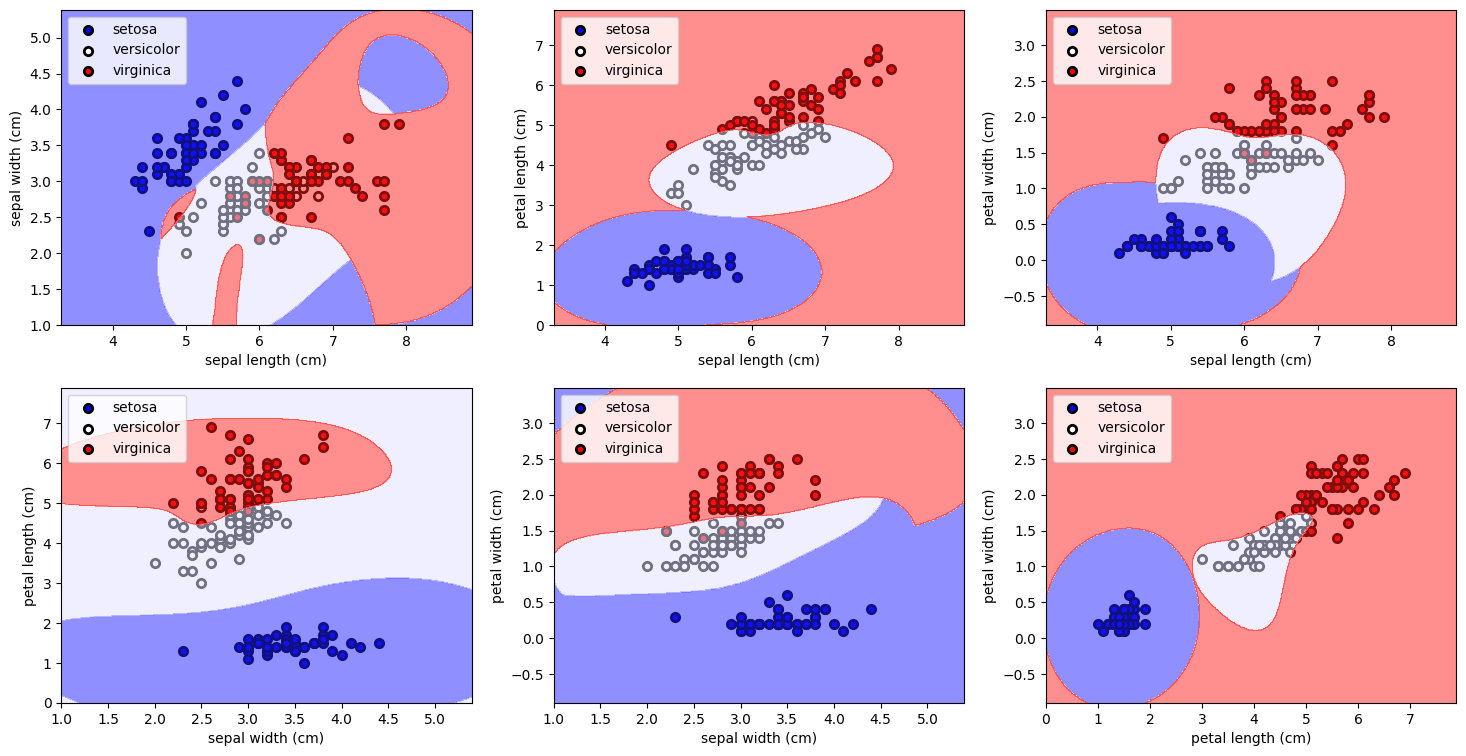

In [ ]:
iris2 = load_iris() # Iris-Datensatz NICHT als Dataframe laden

n_classes = 3
colors = 'bwr'
CMAP = colors # Farbpalette
plot_step = 0.01

fig = plt.figure(1, figsize=(18, 9))

# Berücksichtigung von paarweisen Korrelationen 
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    X = iris2.data[:,pair]
    y = iris2.target

    clf = model_nonlinear.fit(X, y)

    # Plotten jedes einzelnen Subplots
    plt.subplot(2, 3, pairidx + 1)

    # Achsen und Größe des Subplots
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    # Labeln des Subplots
    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]]) 
    plt.axis("tight")

    # Pltten der ausgewerteten Datenpunkte
    for i, color in zip(range(n_classes), colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, edgecolor="black", lw=2, label=iris.target_names[i])
        
    # Plotten und einfärben der getrennten Klassen
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, alpha=0.5, cmap = CMAP)

    plt.axis("tight")
    plt.legend(loc="upper left")